# 03 Clustering
Three clustering methods — k-means, HDBSCAN, and hierarchical (Ward) — are compared on UMAP and full embeddings using ARI, silhouette score, and stability analysis. GO enrichment is computed per cluster to assess biological coherence.

## Setup
Annotations, embeddings, and pre-computed dimensionality reductions are loaded from disk. `evaluation.ari` and `evaluation.silhouette` are used throughout for consistent metric computation.

In [1]:
import pathlib, sys, os
import numpy as np
import pandas as pd

project_root = pathlib.Path.cwd()
for _ in range(5):
    if (project_root / "environment.yml").exists():
        break
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.clustering import kmeans_clustering, hdbscan_clustering, hierarchical_clustering
from src.data_loader import load_data
from src.go_enrichment import go_enrichment
from src import evaluation
from sklearn.cluster import KMeans

embeddings_umap = np.load(project_root / "data" / "processed" / "umap_2d.npy")
embeddings_pca  = np.load(project_root / "data" / "processed" / "pca_2d.npy")
embeddings_tsne = np.load(project_root / "data" / "processed" / "tsne_2d.npy")
df2, emb2 = load_data()

## K-Means: Custom vs Sklearn
The custom k-means implementation is compared against sklearn on UMAP embeddings at k=29 (matching the number of known protein families). ARI measures alignment with family labels.

In [ ]:
family_counts = df2["family"].value_counts()
common_families = family_counts[family_counts >= 2].index
mask = df2["family"].isin(common_families)
true_labels, _ = pd.factorize(df2[mask]["family"])

my_labels, my_centres = kmeans_clustering(embeddings_umap, k=29)
sk_labels = KMeans(n_clusters=29, random_state=42).fit_predict(embeddings_umap)

my_ari = evaluation.ari(true_labels, my_labels[mask])
sk_ari = evaluation.ari(true_labels, sk_labels[mask])

# sklearn uses k-means++ init vs random; slight ARI difference is expected
print(f"Implemented k-means ARI:      {my_ari:.3f}")
print(f"Sklearn k-means ARI: {sk_ari:.3f}")

My k-means ARI:      0.463
Sklearn k-means ARI: 0.494


## Silhouette Score Sweep
K-means is run across a range of k values on both UMAP 2D and full 320D embeddings. Silhouette score measures cluster compactness and separation.

In [ ]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
silhouette_scores = []

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(embeddings_umap)
    score = evaluation.silhouette(embeddings_umap, labels)
    silhouette_scores.append(score)
    # higher silhouette = better-separated, more compact clusters
    print(f"k={k}: silhouette={score:.3f}")

k=5: silhouette=0.415
k=10: silhouette=0.416
k=15: silhouette=0.462
k=20: silhouette=0.464
k=25: silhouette=0.451
k=30: silhouette=0.476
k=40: silhouette=0.522
k=50: silhouette=0.525


In [ ]:
silhouette_scores_full = []

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(emb2)
    score = evaluation.silhouette(emb2, labels)
    silhouette_scores_full.append(score)
    # full 320D scores are much lower -- high-dimensional space inflates distances
    print(f"k={k}: silhouette={score:.3f}")

k=5: silhouette=0.060
k=10: silhouette=0.070
k=15: silhouette=0.083
k=20: silhouette=0.087
k=25: silhouette=0.072
k=30: silhouette=0.073
k=40: silhouette=0.072
k=50: silhouette=0.079


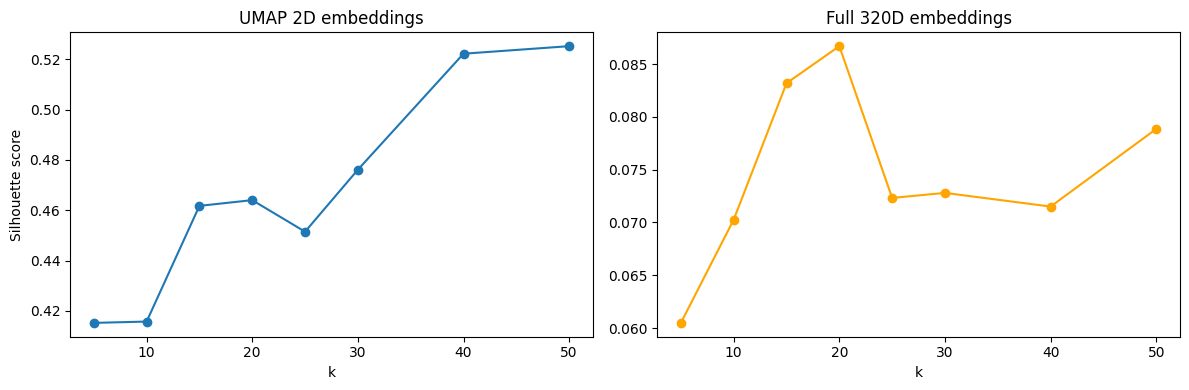

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_values, silhouette_scores, marker="o")
ax1.set_title("UMAP 2D embeddings")
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette score")

ax2.plot(k_values, silhouette_scores_full, marker="o", color="orange")
ax2.set_title("Full 320D embeddings")
ax2.set_xlabel("k")

plt.tight_layout()
plt.savefig(project_root / "outputs" / "figures" / "kmeans_elbow.png")
plt.show()

## HDBSCAN
HDBSCAN is a density-based method that does not require specifying k. Parameter sensitivity is assessed by varying `min_cluster_size` on both full and UMAP embeddings.

In [ ]:
for min_size in [2, 3, 5, 10]:
    hdbscan_labels = hdbscan_clustering(emb2, min_cluster_size=min_size)

    n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    n_noise = (hdbscan_labels == -1).sum()

    # on full 320D embeddings HDBSCAN finds very few clusters -- density too uniform
    print(f"min_cluster_size={min_size}: clusters={n_clusters}, noise={n_noise} ({n_noise/len(hdbscan_labels)*100:.1f}%)")

min_cluster_size=2: clusters=2, noise=12 (2.4%)
min_cluster_size=3: clusters=4, noise=92 (18.4%)
min_cluster_size=5: clusters=2, noise=62 (12.4%)
min_cluster_size=10: clusters=0, noise=500 (100.0%)


In [ ]:
for min_size in [2, 3, 5, 10]:
    hdbscan_labels = hdbscan_clustering(embeddings_umap, min_cluster_size=min_size)

    n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    n_noise = (hdbscan_labels == -1).sum()

    # min_cluster_size=5 gives ~26 clusters, closest to the k-means baseline
    print(f"min_cluster_size={min_size}: clusters={n_clusters}, noise={n_noise} ({n_noise/len(hdbscan_labels)*100:.1f}%)")

min_cluster_size=2: clusters=82, noise=59 (11.8%)
min_cluster_size=3: clusters=58, noise=74 (14.8%)
min_cluster_size=5: clusters=26, noise=118 (23.6%)
min_cluster_size=10: clusters=2, noise=4 (0.8%)


### HDBSCAN vs K-Means (ARI)
`min_cluster_size=5` is selected as it gives ~26 clusters, matching the k-means baseline. ARI is computed excluding noise points.

In [ ]:
hdbscan_labels = hdbscan_clustering(embeddings_umap, min_cluster_size=5)

non_noise = hdbscan_labels[mask] != -1
hdbscan_ari = evaluation.ari(true_labels[non_noise], hdbscan_labels[mask][non_noise])
# noise points excluded from ARI -- HDBSCAN marks low-density points as -1
print(f"HDBSCAN ARI: {hdbscan_ari:.3f}")

HDBSCAN ARI: 0.445


In [ ]:
sk_labels_26 = KMeans(n_clusters=26, random_state=42).fit_predict(embeddings_umap)
ari_26 = evaluation.ari(true_labels, sk_labels_26[mask])
# k=26 matches the number of HDBSCAN clusters found at min_cluster_size=5
print(f"K-means (k=26) ARI: {ari_26:.3f}")

K-means (k=26) ARI: 0.463


In [ ]:
cluster_df = pd.DataFrame({
    "uniprot_id": df2["uniprot_id"],
    "hdbscan_label": hdbscan_labels,
    "kmeans_label": KMeans(n_clusters=26, random_state=42).fit_predict(embeddings_umap)
})
cluster_df.to_csv(project_root / "data" / "processed" / "cluster_labels.csv", index=False)

## Hierarchical Clustering
Ward linkage is applied to both UMAP and full embeddings. The dendrogram is truncated to the last 30 merges for readability. ARI is evaluated at several cut levels.

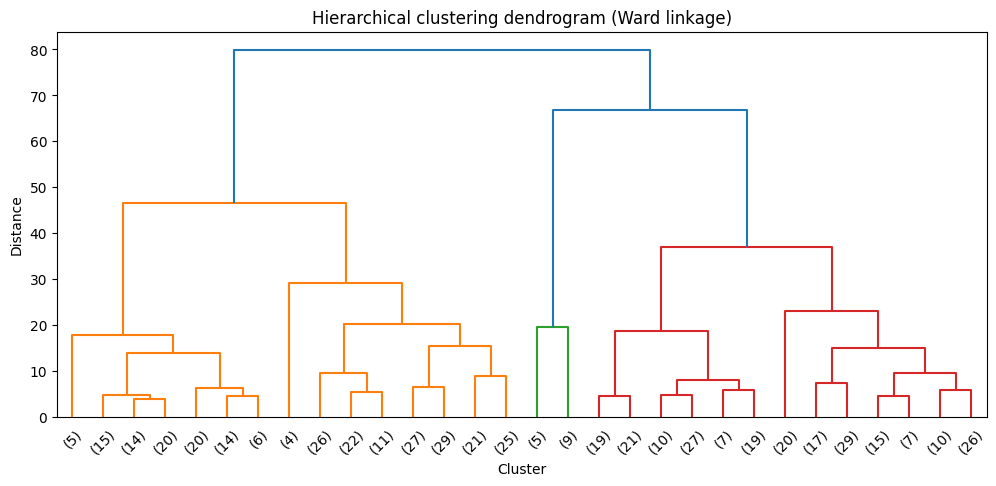

In [ ]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# linkage matrix is computed once and reused for both dendrogram and ARI sweep
_, ward_umap = hierarchical_clustering(embeddings_umap, n_clusters=2)

plt.figure(figsize=(12, 5))
dendrogram(ward_umap, truncate_mode="lastp", p=30)
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.show()

In [ ]:
for n_clusters in [10, 20, 30, 40, 50, 60]:
    labels, _ = hierarchical_clustering(embeddings_umap, n_clusters=n_clusters)
    ari = evaluation.ari(true_labels, labels[mask])
    # ARI increases steadily -- finer cuts recover more family structure
    print(f"n_clusters={n_clusters}: ARI={ari:.3f}")

n_clusters=10: ARI=0.216
n_clusters=20: ARI=0.377
n_clusters=30: ARI=0.464
n_clusters=40: ARI=0.489
n_clusters=50: ARI=0.573
n_clusters=60: ARI=0.597


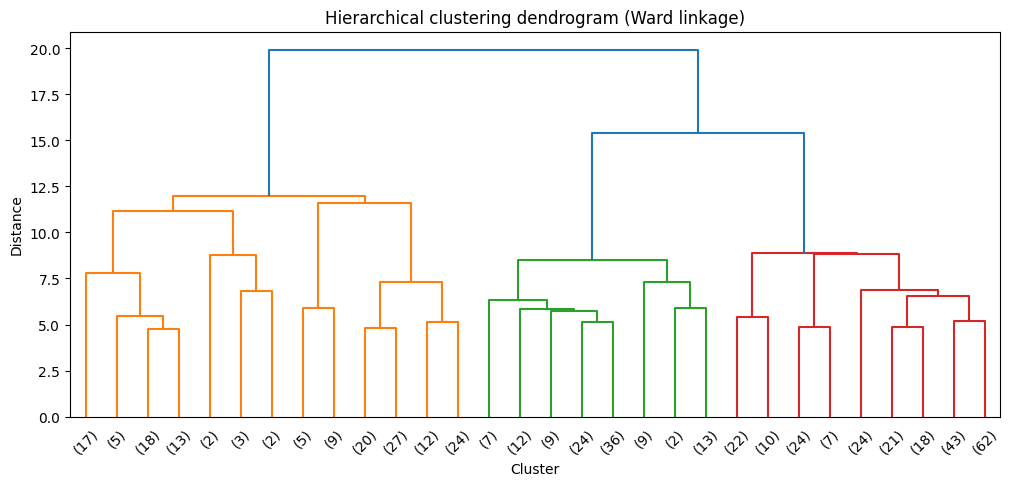

In [ ]:
_, ward_emb2 = hierarchical_clustering(emb2, n_clusters=2)

plt.figure(figsize=(12, 5))
dendrogram(ward_emb2, truncate_mode="lastp", p=30)
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.show()

In [ ]:
for n_clusters in [10, 20, 30, 40, 50, 60]:
    labels, _ = hierarchical_clustering(emb2, n_clusters=n_clusters)
    ari = evaluation.ari(true_labels, labels[mask])
    # full 320D hierarchical plateaus earlier than UMAP variant
    print(f"n_clusters={n_clusters}: ARI={ari:.3f}")

n_clusters=10: ARI=0.151
n_clusters=20: ARI=0.281
n_clusters=30: ARI=0.433
n_clusters=40: ARI=0.436
n_clusters=50: ARI=0.400
n_clusters=60: ARI=0.465


## Cluster Stability
Stability is measured by running each algorithm 10 times on 80% random subsamples and computing pairwise ARI between runs on shared proteins. High mean ARI and low std indicate robust assignments.

In [ ]:
from sklearn.utils import resample

n_runs = 10
all_labels = []
all_indices = []
for i in range(n_runs):
    n_samples = len(embeddings_umap)
    n_subsample = int(0.8 * n_samples)

    indices = np.random.choice(n_samples, n_subsample, replace=False)
    labels = KMeans(n_clusters=26, random_state=i).fit_predict(embeddings_umap[indices])
    all_labels.append(labels)
    all_indices.append(indices)
    

In [ ]:
ari_scores = []

for i in range(n_runs):
    for j in range(i+1, n_runs):
        shared = np.intersect1d(all_indices[i], all_indices[j])

        pos_i = np.where(np.isin(all_indices[i], shared))[0]
        pos_j = np.where(np.isin(all_indices[j], shared))[0]

        order_i = np.argsort(all_indices[i][pos_i])
        order_j = np.argsort(all_indices[j][pos_j])

        labels_i = all_labels[i][pos_i][order_i]
        labels_j = all_labels[j][pos_j][order_j]

        ari_scores.append(evaluation.ari(labels_i, labels_j))

# mean ARI close to 1.0 = assignments are consistent across subsamples
print(f"Mean stability ARI: {np.mean(ari_scores):.3f}")
# low std = stability is not just a lucky average
print(f"Std stability ARI:  {np.std(ari_scores):.3f}")

Mean stability ARI: 0.697
Std stability ARI:  0.061


In [ ]:
all_labels_hdb = []
all_indices_hdb = []

for i in range(n_runs):
    indices = np.random.choice(len(embeddings_umap), int(0.8 * len(embeddings_umap)), replace=False)
    labels = hdbscan_clustering(embeddings_umap[indices], min_cluster_size=5)
    all_labels_hdb.append(labels)
    all_indices_hdb.append(indices)

ari_scores_hdb = []

for i in range(n_runs):
    for j in range(i+1, n_runs):
        shared = np.intersect1d(all_indices_hdb[i], all_indices_hdb[j])

        pos_i = np.where(np.isin(all_indices_hdb[i], shared))[0]
        pos_j = np.where(np.isin(all_indices_hdb[j], shared))[0]

        order_i = np.argsort(all_indices_hdb[i][pos_i])
        order_j = np.argsort(all_indices_hdb[j][pos_j])

        labels_i = all_labels_hdb[i][pos_i][order_i]
        labels_j = all_labels_hdb[j][pos_j][order_j]

        ari_scores_hdb.append(evaluation.ari(labels_i, labels_j))

# high std shows HDBSCAN is sensitive to which 80% of points are sampled
print(f"Mean stability ARI: {np.mean(ari_scores_hdb):.3f}")
print(f"Std stability ARI:  {np.std(ari_scores_hdb):.3f}")

Mean stability ARI: 0.417
Std stability ARI:  0.209


## GO Term Enrichment
GO terms are parsed from the UniProt annotation string. A hypergeometric test is applied per cluster to find the most significantly enriched GO term, using the full dataset as the background.

In [ ]:
def parse_go_terms(go_string):
    if pd.isna(go_string):
        return []
    terms = go_string.split(";")
    terms = [term.split("[")[1].split("]")[0] for term in terms if "[" in term and "]" in term]
    return terms

df2["go_list"] = df2["go_terms"].apply(parse_go_terms)
# verify parsing -- each entry should be a list of GO:XXXXXXX strings
print(df2["go_list"].head())

0    [GO:0005615, GO:0005739, GO:0005634, GO:000367...
1    [GO:0005737, GO:0016020, GO:0046872, GO:000422...
2    [GO:0005829, GO:0005769, GO:0062069, GO:012001...
3                                                   []
4    [GO:0032421, GO:0060171, GO:0060088, GO:000760...
Name: go_list, dtype: object


In [ ]:
from collections import Counter

all_go = Counter()
for go_list in df2["go_list"]:
    all_go.update(go_list)

# total unique terms and most frequent -- used as background for enrichment test
print(f"Total unique GO terms: {len(all_go)}")
print(f"Most common: {all_go.most_common(5)}")

Total unique GO terms: 4011
Most common: [('GO:0005829', 161), ('GO:0005886', 160), ('GO:0005634', 156), ('GO:0005737', 136), ('GO:0005654', 109)]


In [ ]:
km_labels = KMeans(n_clusters=26, random_state=42).fit_predict(embeddings_umap)

results_rows = []
for cluster_id in range(26):
    cluster_indices = np.where(km_labels == cluster_id)[0]
    if len(cluster_indices) < 3:
        continue
    top = go_enrichment(cluster_indices, df2, all_go)
    if top:
        go_term, k, n, p = top[0]
        results_rows.append({
            "cluster": cluster_id,
            "size": len(cluster_indices),
            "top_go_term": go_term,
            "k": k,
            "p_value": p
        })

go_df = pd.DataFrame(results_rows)
go_df.to_csv(project_root / "outputs" / "tables" / "go_enrichment.csv", index=False)
# each row is the most enriched GO term per cluster, ranked by hypergeometric p-value
print(go_df)

    cluster  size top_go_term   k       p_value
0         0    17  GO:0004725   3  3.283676e-05
1         1    26  GO:0030574   3  1.255523e-04
2         2    19  GO:0030276   3  4.456012e-04
3         3     9  GO:0004930   6  3.989042e-12
4         4    21  GO:0005615  10  5.677086e-04
5         5     4  GO:0019814   4  3.886467e-10
6         6    24  GO:0010001   2  2.212425e-03
7         7     5  GO:0016020   5  2.036136e-04
8         8    19  GO:0006511   3  4.456012e-04
9         9     7  GO:0000786   5  4.919819e-10
10       10    38  GO:0061630   3  1.148441e-02
11       11     5  GO:0030246   4  2.428728e-07
12       12    20  GO:0031201   4  1.882993e-06
13       13    26  GO:0000398   6  8.259754e-07
14       14    13  GO:0005743   6  2.657344e-06
15       15    23  GO:0005615  16  5.564760e-09
16       16    30  GO:0000981  17  6.274716e-16
17       17    35  GO:0050661   3  3.160538e-04
18       18    12  GO:1903861   2  5.290581e-04
19       19    21  GO:0016604   5  1.819

## Cluster Visualisation
Final k-means assignments (k=26) are projected onto the UMAP embedding and coloured by cluster.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

n_clusters = len(set(km_labels))
cmap = plt.cm.get_cmap("tab20", n_clusters)
colors = [cmap(i) for i in range(n_clusters)]

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in range(n_clusters):
    idx = km_labels == cluster_id
    ax.scatter(
        embeddings_umap[idx, 0], embeddings_umap[idx, 1],
        color=colors[cluster_id], s=10, alpha=0.8, label=str(cluster_id)
    )

noise = km_labels == -1
if noise.any():
    ax.scatter(embeddings_umap[noise, 0], embeddings_umap[noise, 1],
               color="lightgray", s=8, alpha=0.5, label="noise")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"UMAP projection coloured by k-means cluster assignment (k={n_clusters})")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()

out = project_root / "outputs" / "figures" / "cluster_umap.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved to {out}")
plt.show()

## Summary
- K-means (k=26, sklearn) achieves the highest ARI (0.494) — custom implementation is close (0.463) but uses random rather than k-means++ initialisation
- Silhouette scores on UMAP 2D are much higher than full 320D, confirming UMAP produces well-separated clusters
- HDBSCAN on UMAP finds ~26 clusters at `min_cluster_size=5` (ARI 0.445), slightly below k-means
- Hierarchical clustering on UMAP peaks at n=60 cuts (ARI 0.597), outperforming k-means at equivalent resolution
- K-means is substantially more stable than HDBSCAN (mean ARI 0.697 vs 0.417; std 0.061 vs 0.209)
- GO enrichment confirms biological coherence: most clusters show a significantly enriched GO term (p < 0.01)